In [1]:
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import time
import torch.optim as optim
import torch.nn.functional as F
from torch.utils.data import DataLoader

from torchvision import datasets, transforms

torch.backends.cuda.matmul.allow_tf32 = True
torch.backends.cudnn.allow_tf32 = True

In [2]:
random_seed = 42
lr = 0.001
batch_size = 64
epochs = 10
num_classes = 10

In [3]:
transform = transforms.Compose([transforms.ToTensor()])

train_dataset = datasets.MNIST(root='./data', train=True, download=True, transform=transform)
test_dataset = datasets.MNIST(root='./data', train=False, download=True, transform=transform)

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

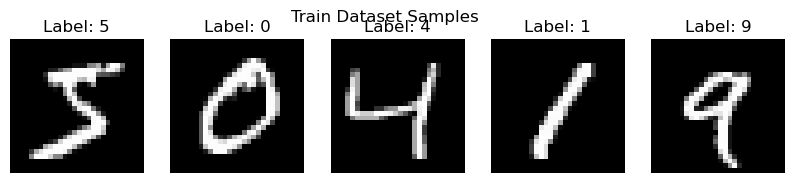

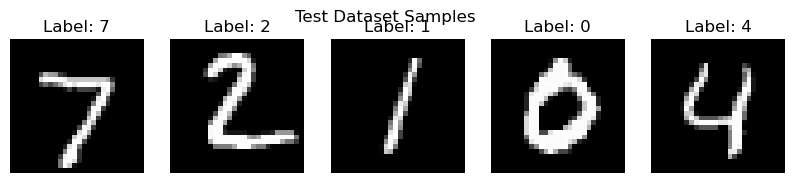

Train dataset size: 60000
Train dataset classes: ['0 - zero', '1 - one', '2 - two', '3 - three', '4 - four', '5 - five', '6 - six', '7 - seven', '8 - eight', '9 - nine']
Size of each data sample in train_dataset: torch.Size([1, 28, 28])
Type of image: <class 'torch.Tensor'>, Type of label: <class 'int'>


In [4]:
def show_images(dataset, title, num_images=5):
    plt.figure(figsize=(10, 2))
    for i in range(num_images):
        image, label = dataset[i]
        plt.subplot(1, num_images, i + 1)
        plt.imshow(image.squeeze(), cmap='gray')
        plt.title(f'Label: {label}')
        plt.axis('off')
    plt.suptitle(title)
    plt.show()

show_images(train_dataset, 'Train Dataset Samples')
show_images(test_dataset, 'Test Dataset Samples')

print(f'Train dataset size: {len(train_dataset)}')
print(f'Train dataset classes: {train_dataset.classes}')
# Each item in the dataset is a tuple: (image, label)
# image: torch.Tensor of shape [1, 28, 28] (grayscale MNIST image)
# label: int (digit class 0-9)
print(f'Size of each data sample in train_dataset: {train_dataset[0][0].shape}')
print(f'Type of image: {type(train_dataset[0][0])}, Type of label: {type(train_dataset[0][1])}')

In [5]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [6]:
class AutoEncoder(nn.Module):
    def __init__(self, latent_dim=32):
        super().__init__()

        # Encoder
        self.encoder = nn.Sequential(
            nn.Conv2d(1, 16, kernel_size=3, padding=1),  # 1x28x28 -> 16x28x28
            nn.BatchNorm2d(16),
            nn.ReLU(),
            nn.MaxPool2d(2),                             # 16x28x28 -> 16x14x14

            nn.Conv2d(16, 32, kernel_size=3, padding=1), # 16x14x14 -> 32x14x14
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.MaxPool2d(2),                             # 32x14x14 -> 32x7x7

            nn.Conv2d(32, 64, kernel_size=3, padding=1), # 32x7x7 -> 64x7x7
            nn.BatchNorm2d(64),
            nn.ReLU()
        )

        # Bottleneck Down: encoder to latent
        self.bottleneck_down = nn.Sequential(
            nn.Flatten(),                          # 64x7x7 -> 3136
            nn.Linear(64 * 7 * 7, latent_dim),
            nn.ReLU()
        )
        # Bottleneck Up: latent to decoder
        self.bottleneck_up = nn.Sequential(
            nn.Linear(latent_dim, 64 * 7 * 7),
            nn.ReLU(),
            nn.Unflatten(1, (64, 7, 7))            # -> 64x7x7
        )

        # Decoder
        self.decoder = nn.Sequential(
            nn.ConvTranspose2d(64, 32, kernel_size=2, stride=2),  # 64x7x7 -> 32x14x14
            nn.BatchNorm2d(32),
            nn.ReLU(),

            nn.ConvTranspose2d(32, 16, kernel_size=2, stride=2),  # 32x14x14 -> 16x28x28
            nn.BatchNorm2d(16),
            nn.ReLU(),

            nn.Conv2d(16, 1, kernel_size=3, padding=1),           # 16x28x28 -> 1x28x28
            nn.Sigmoid()                                          # Final output
        )

    def forward(self, x):
        x = self.encoder(x)
        x = self.bottleneck_down(x)
        x = self.bottleneck_up(x)
        x = self.decoder(x)
        return x
    
    def get_latents(self, x):
        x = self.encoder(x)
        x = self.bottleneck_down(x)
        return x

In [7]:
model = AutoEncoder().to(device)
print(model)

AutoEncoder(
  (encoder): Sequential(
    (0): Conv2d(1, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(16, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (4): Conv2d(16, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (5): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (6): ReLU()
    (7): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (8): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (9): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (10): ReLU()
  )
  (bottleneck_down): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=3136, out_features=32, bias=True)
    (2): ReLU()
  )
  (bottleneck_up): Sequential(
    (0): Linear(in_features=32, out_features=3136, bias=True)


In [8]:
from IPython.display import clear_output

def plot_losses(training_losses, test_losses):
    clear_output(wait=True)
    plt.figure(figsize=(8, 5))
    plt.plot(training_losses, label='Train Loss')
    plt.plot(test_losses, label='Test Loss')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.title('Training and Test Losses')
    plt.legend()
    plt.grid(True)
    plt.show()



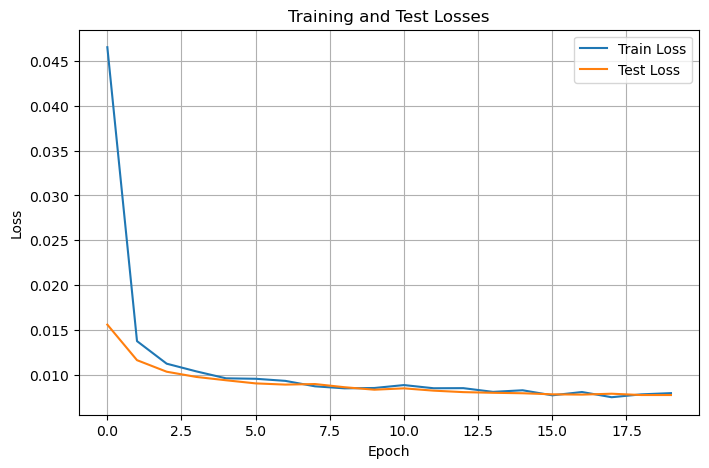

In [9]:
torch.manual_seed(random_seed)

num_epochs = 20
optimizer = optim.Adam(model.parameters(), lr=lr)
criterion = nn.MSELoss()

test_losses = []
training_losses = []

for epoch in range(num_epochs):
    model.train()
    batch_losses = []
    for batch_idx, (data, _) in enumerate(train_loader):
        data = data.to(device)
        optimizer.zero_grad()

        output = model(data)
        loss = criterion(output, data)
        loss.backward()
        optimizer.step()

        if batch_idx % 100 == 0:
            batch_losses.append(loss.item())
            print(f'Epoch [{epoch+1}/{num_epochs}], Batch [{batch_idx+1}/{len(train_loader)}], Loss: {loss.item():.4f}')
    avg_loss = np.mean(batch_losses)
    print(f'Epoch [{epoch+1}/{num_epochs}] Average Loss: {avg_loss:.4f}')
    training_losses.append(avg_loss)

    # Evaluate test loss
    model.eval()
    test_loss = 0
    with torch.no_grad():
        for data, _ in test_loader:
            data = data.to(device)
            output = model(data)
            loss = criterion(output, data)
            test_loss += loss.item() * data.size(0)
    test_loss /= len(test_loader.dataset)
    test_losses.append(test_loss)
    print(f'Epoch [{epoch+1}/{num_epochs}] Test Loss: {test_loss:.4f}')

    plot_losses(training_losses, test_losses)

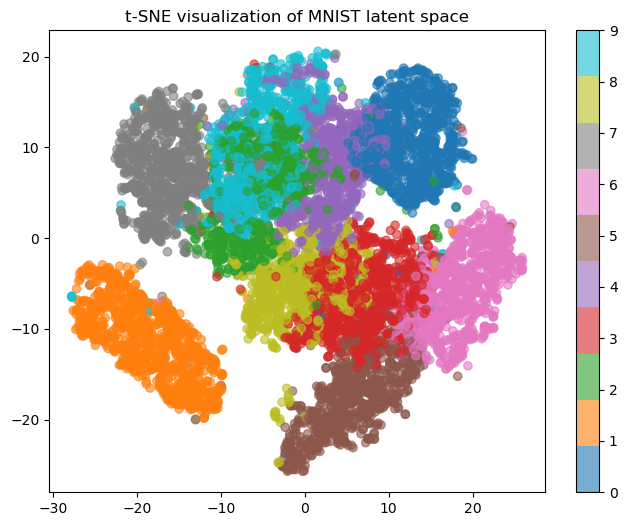

In [10]:
from sklearn.manifold import TSNE
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

# Collect latent vectors and labels
latents = []
labels = []
with torch.no_grad():
    for imgs, lbls in test_loader:
        encoded = model.encoder(imgs.to(device))
        # print(f"encoded image shape: {encoded.shape}") # (batch_size, 64, 7, 7)
        z = model.bottleneck_down[1](encoded.view(imgs.size(0), -1))  # (batch_size, latent_dim)
        latents.append(z.cpu())
        labels.append(lbls)

latents = torch.cat(latents).numpy()
labels = torch.cat(labels).numpy()

# Apply t-SNE or PCA
tsne = TSNE(n_components=3, perplexity=30)
z_2d = tsne.fit_transform(latents)

# Plot
plt.figure(figsize=(8, 6))
scatter = plt.scatter(z_2d[:, 0], z_2d[:, 1], c=labels, cmap='tab10', alpha=0.6)
plt.colorbar(scatter, ticks=range(10))
plt.title("t-SNE visualization of MNIST latent space")
plt.show()

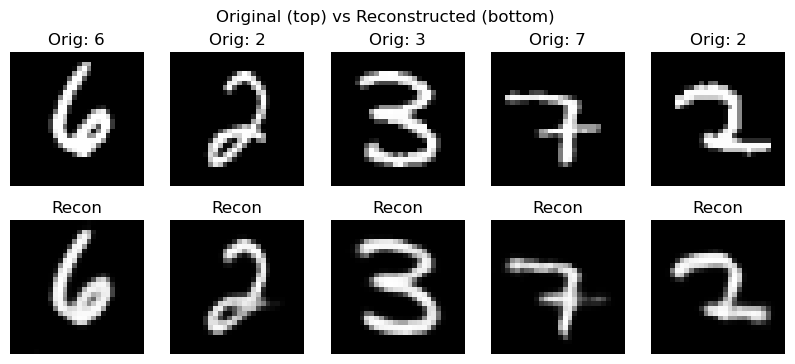

In [11]:
np.random.seed(random_seed)
indices = np.random.choice(len(test_dataset), size=5, replace=False)
sample_images = [test_dataset[i][0] for i in indices]
sample_labels = [test_dataset[i][1] for i in indices]

with torch.no_grad():
    batch = torch.stack(sample_images).to(device)
    reconstructed = model(batch)

    plt.figure(figsize=(10, 4))
    for i in range(5):
        # Original image
        plt.subplot(2, 5, i + 1)
        plt.imshow(batch[i].cpu().squeeze(), cmap='gray')
        plt.title(f'Orig: {sample_labels[i]}')
        plt.axis('off')
        # Reconstructed image
        plt.subplot(2, 5, i + 6)
        plt.imshow(reconstructed[i].cpu().squeeze(), cmap='gray')
        plt.title('Recon')
        plt.axis('off')
    plt.suptitle('Original (top) vs Reconstructed (bottom)')
    plt.show()


torch.Size([2, 32])


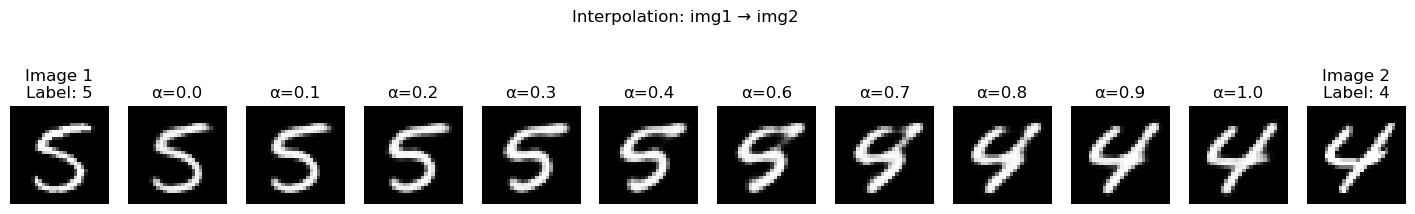

In [17]:
# Get two images.
label1, label2 = 0, 0
while label1 == label2:
    indices = np.random.choice(len(test_dataset), size=2, replace=False)
    sample_images = [test_dataset[i][0] for i in indices]
    sample_labels = [test_dataset[i][1] for i in indices]
    img1, img2 = sample_images
    label1, label2 = sample_labels

# Convert images to latent vectors z1,z2
z = model.get_latents(torch.stack([img1, img2]).to(device))
print(z.shape)
z1 = z[0].cpu()
z2 = z[1].cpu()

with torch.no_grad():
    alphas = np.linspace(0, 1, 10)
    interpolated_imgs = [a * z2 + (1 - a) * z1 for a in alphas]
    with torch.no_grad():
        x = model.bottleneck_up(torch.stack(interpolated_imgs).to(device))
        recons = model.decoder(x).cpu()

    plt.figure(figsize=(18, 3))
    # Draw img1
    plt.subplot(1, len(alphas) + 2, 1)
    plt.imshow(img1.squeeze().cpu(), cmap='gray')
    plt.title(f'Image 1\nLabel: {label1}')
    plt.axis('off')

    # Draw reconstructions
    for i, (a, recon) in enumerate(zip(alphas, recons)):
        plt.subplot(1, len(alphas) + 2, i + 2)
        plt.imshow(recon.squeeze(), cmap='gray')
        plt.title(f'α={a:.1f}')
        plt.axis('off')

    # Draw img2
    plt.subplot(1, len(alphas) + 2, len(alphas) + 2)
    plt.imshow(img2.squeeze().cpu(), cmap='gray')
    plt.title(f'Image 2\nLabel: {label2}')
    plt.axis('off')

    plt.suptitle('Interpolation: img1 → img2')
    plt.show()

TypeError: stack(): argument 'tensors' (position 1) must be tuple of Tensors, not Tensor

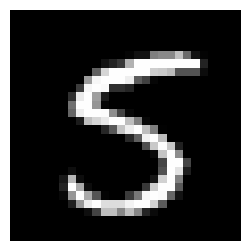

In [ ]:
from matplotlib.animation import FuncAnimation
from IPython.display import HTML

fig, ax = plt.subplots(figsize=(3, 3))
im = ax.imshow(img1.squeeze().cpu(), cmap='gray', animated=True)
ax.axis('off')

def animate(i):
    alpha = i / 59  # 60 frames for smoothness
    interpolated = (1 - alpha) * z1 + alpha * z2
    with torch.no_grad():
        # recon = model(interpolated.unsqueeze(0).to(device)).cpu().squeeze()
        x = model.bottleneck_up(interpolated.unsqueeze(0).to(device))
        recon = model.decoder(x).cpu().squeeze()
    im.set_array(recon)
    ax.set_title(f'α={alpha:.2f}')
    return [im]

ani = FuncAnimation(fig, animate, frames=60, interval=50, blit=True)
plt.close(fig)
HTML(ani.to_jshtml())